In [ ]:
import spacy
import pandas as pd
import seaborn as sn
import numpy as np
from sklearn.model_selection import train_test_split
from  sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt
nlp = spacy.load("en_core_web_sm")
dft = pd.read_csv("18) fake_news.csv", nrows = 1000)
dff = pd.read_csv("19) true_news.csv", nrows = 1000)
dft["output"] = "True"
dff["output"] = "False"
df = pd.concat([dft,dff])
df.drop(["title", "subject","date"], axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df["vector"] = df['text'].apply(lambda x: nlp(x).vector)
df.drop(["text"], axis=1, inplace=True)
print(df["output"].value_counts())
x_train, x_test, y_train, y_test = train_test_split(df.vector.values, df.output, test_size=0.2, random_state=45)
x_train_2d = np.stack(x_train)
x_test_2d = np.stack(x_test)
df

output
True     1000
False    1000
Name: count, dtype: int64


,output,vector
0,True,"[-0.09723672, -0.28588608, 0.097921215, 0.0351..."
1,True,"[0.122361, -0.25224108, 0.13727504, 0.19161104..."
2,True,"[-0.12878966, -0.2605854, 0.058917742, 0.03514..."
3,True,"[0.011691263, -0.28981125, 0.118149325, 0.0192..."
4,True,"[0.07202872, -0.22451767, 0.0041340827, 0.0344..."
...,...,...
1995,False,"[0.04146214, -0.24274568, -0.051945, 0.192677,..."
1996,False,"[0.13349009, -0.17832099, 0.0647915, 0.0985062..."
1997,False,"[0.09766177, -0.35799062, -0.017909799, 0.2240..."
1998,False,"[0.031291205, -0.2526457, 0.028676711, 0.11151..."


In [ ]:
scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(x_train_2d)
scaled_test_embed = scaler.transform(x_test_2d)
clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)
y_pred = clf.predict(scaled_test_embed)
print("Classification Report by Multinomial Naive Bayes",classification_report(y_test, y_pred))
clf = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')
clf.fit(x_train_2d, y_train)
y_pred = clf.predict(x_test_2d)
print("Classification Report by K-Neighbors Classifier",classification_report(y_test, y_pred))

Classification Report by Multinomial Naive Bayes               precision    recall  f1-score   support

       False       0.93      0.92      0.92       192
        True       0.92      0.94      0.93       208

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

Classification Report by K-Neighbors Classifier               precision    recall  f1-score   support

       False       0.96      0.98      0.97       192
        True       0.99      0.97      0.98       208

    accuracy                           0.97       400
   macro avg       0.97      0.98      0.97       400
weighted avg       0.98      0.97      0.98       400



Text(95.72222222222221, 0.5, 'Truth')

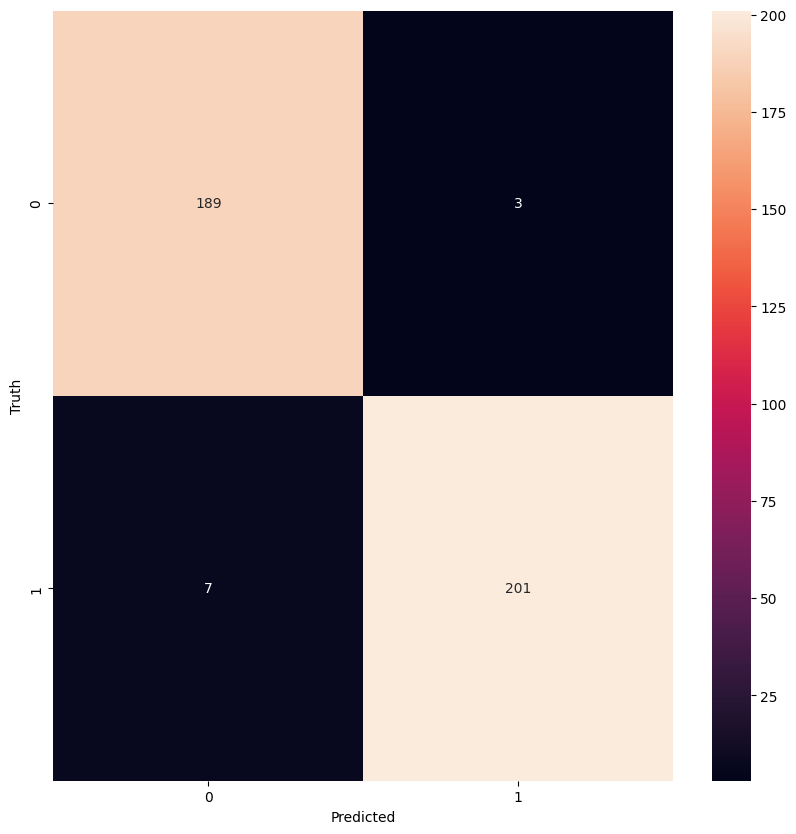

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,10))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')